KNN
1. Dataset Loading and Preprocessing
Load the MNIST dataset and split it into training, and test sets(70-30). Inspect the shape of the dataset and display a few sample images with their corresponding labels. Normalize the pixel values and investigate whether feature scaling affects KNN performance.
You may find the following link useful https://medium.com/@adnan.mazraeh1993/feature-scaling-from-basic-to-super-advanced-1-3519644eb5c8

Feature Scaling: From Basic to Super Advanced
* What is the dimensionality of each input sample?
* Compare the performance of KNN with and without feature scaling.
* Does feature scaling significantly matter for MNIST? Explain why.

X Shape: (70000, 784), Y Shape: (70000,)


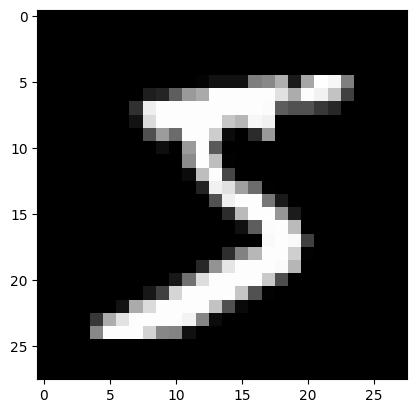

Class Label: 5


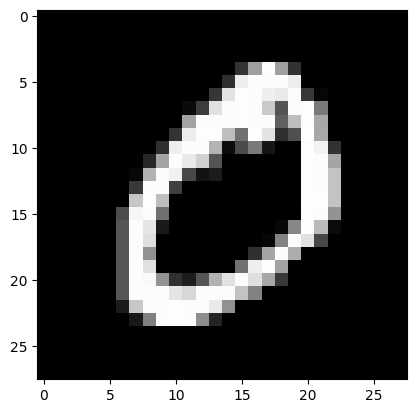

Class Label: 0


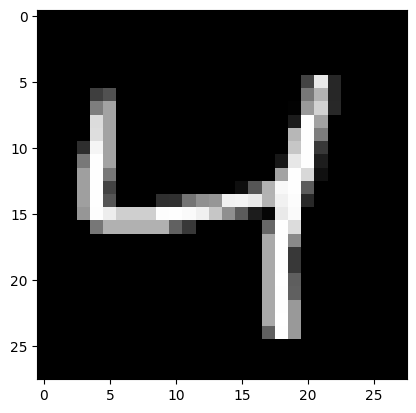

Class Label: 4


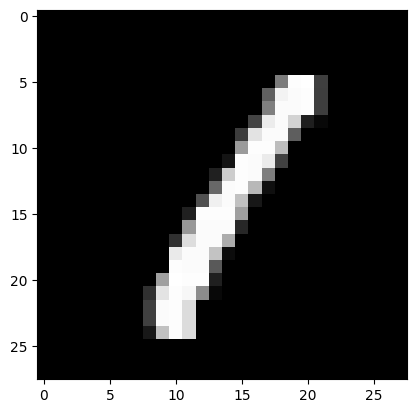

Class Label: 1


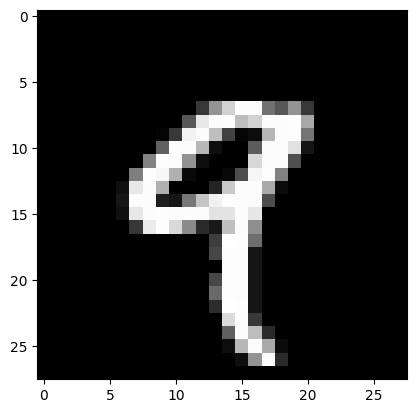

Class Label: 9


In [103]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
import time

time_taken={}

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)

print(f"X Shape: {X.shape}, Y Shape: {y.shape}")
X_train, X_test, y_train, y_test = X[:49000], X[49000:], y[:49000], y[49000:]

for i in range(5):
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.show()
    print(f"Class Label: {y_train[i]}")

In [104]:
X_train, X_test, y_train, y_test = X[:5000], X[5000:5100], y[:5000], y[5000:5100]
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

confMatrix = np.zeros((10,10))
confMatrix_scaled = np.zeros((10,10))

K=3
for i in range(len(X_test)):
    predicted = predict(X_test[i], X_train, "euclidean")
    predicted_scaled = predict(X_test_scaled[i], X_train_scaled, "euclidean")
    true = y_test[i]
    confMatrix[true, predicted] += 1
    confMatrix_scaled[true, predicted_scaled] += 1

accuracy = np.trace(confMatrix) / np.sum(confMatrix)
accuracy_scaled = np.trace(confMatrix_scaled) / np.sum(confMatrix_scaled)

print("Accuracy: ", accuracy)
print("Accuracy scaled: ", accuracy_scaled)

Accuracy:  0.95
Accuracy scaled:  0.95



* Each input sample has dimensions 1x784 (28x28 pixels flattened to a vector).
* The performance of KNN with and without feature scaling is the same.
* No, feature scaling does not significantly matter for MNIST. KNN only looks at the k nearest neighbors, so it does not matter if the features are scaled or not as the distance will also scale accordingly.

2. Implement KNN from Scratch
Implement the K-Nearest Neighbors (KNN) algorithm from scratch without using a pre-built
KNN classifier. Your implementation should:
(a) Calculate the Euclidean distance between samples.

In [105]:
def eudists(x, train):
    return np.array([np.sqrt(np.sum((x - y) ** 2)) for y in train])

def mandists(x, train):
    return np.array([np.sum(np.abs(x - y)) for y in X_train])

(b) Find the k nearest training samples.

In [106]:

K = 3

def k_nearest(x, train, type):
    if type == 'euclidean':
        k_indices = np.argsort(eudists(x, train))[:K]
    elif type == 'manhattan':
        k_indices = np.argsort(mandists(x, train))[:K]
    return k_indices

(c) Predict the class using majority voting.
Evaluate your implementation on a subset of MNIST(try taking 5000 train points and
200 test points) and report the classification accuracy and confusion matrix.

In [107]:
def predict(x, train, type):
    k_nearest_labels = [y_train[i] for i in k_nearest(x, train, type)]
    most_common = np.bincount(k_nearest_labels).argmax()
    return most_common



X_train, X_test, y_train, y_test = X[:5000], X[5000:5100], y[:5000], y[5000:5100]

confMatrix = np.zeros((10,10))

start_time = time.perf_counter()
for i in range(len(X_test)):
    predicted = predict(X_test[i], X_train, "euclidean")
    true = y_test[i]
    confMatrix[true, predicted] += 1
time_taken["euclidean"] = (time.perf_counter() - start_time) / len(X_test)

accuracy = np.trace(confMatrix) / np.sum(confMatrix)

print(accuracy)
print(confMatrix)

0.95
[[12.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 11.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  5.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. 11.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 11.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  7.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. 12.  0.  0.  0.]
 [ 1.  0.  0.  0.  0.  0.  0.  9.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  1.  0.  9.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  8.]]


3. Choosing the Value of k
Evaluate KNN using multiple values of k, for example
k ∈ {1, 3, 5, 7, 9, 11}.
Plot the test error against k for
k = 1, 2, . . . , N.
Identify the value of k that gives the lowest test error and briefly explain why very small and
very large values of k can lead to overfitting and underfitting, respectively.

In [108]:
accuraciesK = {}

for k in [1,3,5,7,9,11, 13, 15]:
    K = k
    
    confMatrix = np.zeros((10,10))

    for i in range(len(X_test)):
        predicted = predict(X_test[i], X_train, "euclidean")
        true = y_test[i]
        confMatrix[true, predicted] += 1

    accuraciesK[k] = np.trace(confMatrix) / np.sum(confMatrix)

print(accuraciesK)
bestK = max(accuraciesK, key=accuraciesK.get)
print(bestK)


{1: 0.95, 3: 0.95, 5: 0.96, 7: 0.96, 9: 0.96, 11: 0.97, 13: 0.95, 15: 0.93}
11


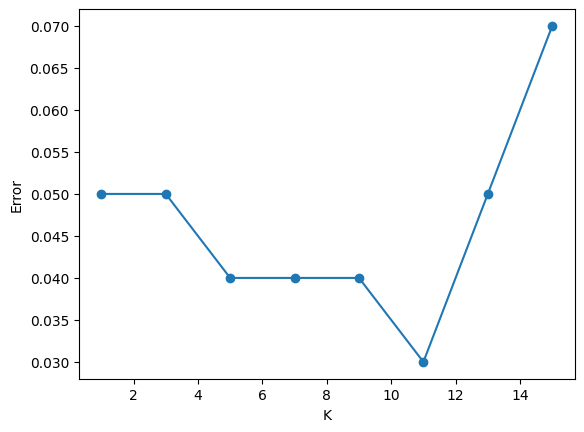

In [109]:
plt.plot(accuraciesK.keys(), [1 - x for x in accuraciesK.values()], 'o-')
plt.xlabel('K')
plt.ylabel('Error')
plt.show()

Very small values of k lead to overfitting because when k is small, the model is highly sensitive to the local structure and noise of the training data.
Very large values of k lead to underfitting because when k is large, the model will always predict the class with most data points in the training dataset, as a very large part of the dataset will be considered.

4. Investigate Distance Metrics
Compare KNN using different distance metrics:
* Euclidean distance
* Manhattan distance
You may find the following link useful
https://www.geeksforgeeks.org/data-science/manhattan-distance/ Manhattan Distance
Evaluate both methods using the same value of k and compare their test accuracy. Briefly
explain how the choice of distance metric affects KNN predictions and which metric performs
better on the MNIST dataset.

In [110]:
K = 5

accuraciesT = {}

for type in ["euclidean","manhattan"]:
    confMatrix = np.zeros((10,10))

    for i in range(len(X_test)):
        predicted = predict(X_test[i], X_train, type)
        true = y_test[i]
        confMatrix[true, predicted] += 1

    accuraciesT[type] = np.trace(confMatrix) / np.sum(confMatrix)

print(accuraciesT)

{'euclidean': 0.96, 'manhattan': 0.92}


The choice of distance metric affect KNN predictions majorly, by changing which data points are considered closer to the query point. On the MNIST dataset, we can see that the Euclidean distance is the most suitable distance metric for KNN.

5. Final Analysis
Summarize the results of all experiments in a table containing the feature scaling method,
number of features, best value of k, test accuracy, and prediction time.
Finally, answer the following:
* What value of k performed best?
* Did feature scaling improve KNN performance on MNIST?
* What are the main advantages and disadvantages of KNN for image classification?

In [111]:
accuraciesKman = {}

start_time = time.perf_counter()
for k in [1,3,5,7,9,11, 13, 15]:
    K = k
    
    confMatrix = np.zeros((10,10))

    for i in range(len(X_test)):
        predicted = predict(X_test[i], X_train, "manhattan")
        true = y_test[i]
        confMatrix[true, predicted] += 1

    accuraciesKman[k] = np.trace(confMatrix) / np.sum(confMatrix)
time_taken["manhattan"] = (time.perf_counter() - start_time) / (len(X_test) * len([1,3,5,7,9,11, 13, 15]))

print(accuraciesKman)
bestKman = max(accuraciesKman, key=accuraciesKman.get)
print(bestKman)

{1: 0.92, 3: 0.91, 5: 0.92, 7: 0.93, 9: 0.93, 11: 0.92, 13: 0.92, 15: 0.92}
7


In [112]:

data = {
    "Feature Scaling Method": [
        "None (Unscaled)", 
        "Normalized (X / 255)", 
        "None (Unscaled)"
    ],
    "Number of Features": [784, 784, 784],
    "Best Value of k": [11, 11, 7],
    "Distance Metric": ["Euclidean", "Euclidean", "Manhattan"],
    "Test Accuracy": ["97.0%", "97.0%", "93.0%"],
    "Time Taken": [time_taken["euclidean"],time_taken["euclidean"],time_taken["manhattan"]]
}

df = pd.DataFrame(data)

print(df)

  Feature Scaling Method  Number of Features  Best Value of k Distance Metric  \
0        None (Unscaled)                 784               11       Euclidean   
1   Normalized (X / 255)                 784               11       Euclidean   
2        None (Unscaled)                 784                7       Manhattan   

  Test Accuracy  Time Taken  
0         97.0%    0.055690  
1         97.0%    0.055690  
2         93.0%    0.050285  


* The best performing value for k was 11.
* No, feature scaling did not improve the performance of the model.
* The advantages of using KNN for image classification are its simplicity and its lack of a training phase. Its disadvantages are its high computational cost and its vulnerability to high image dimensions (High-resolution images have thousands of pixels, making distance measures between images lose their meaning).